Train/Test split successful!
Training samples: 1776, Testing samples: 445
Epoch 0: add loss: 1.7524693012237549
Epoch 10: add loss: 1.3417768478393555
Epoch 20: add loss: 0.9121776223182678
Epoch 30: add loss: 0.8554979562759399
Epoch 40: add loss: 0.7936862707138062
Epoch 50: add loss: 0.7302762866020203
Epoch 60: add loss: 0.6473400592803955
Epoch 70: add loss: 0.5730897784233093
Epoch 80: add loss: 0.4941054880619049
Epoch 90: add loss: 0.4391455054283142


RuntimeError: Parent directory ../../models does not exist.

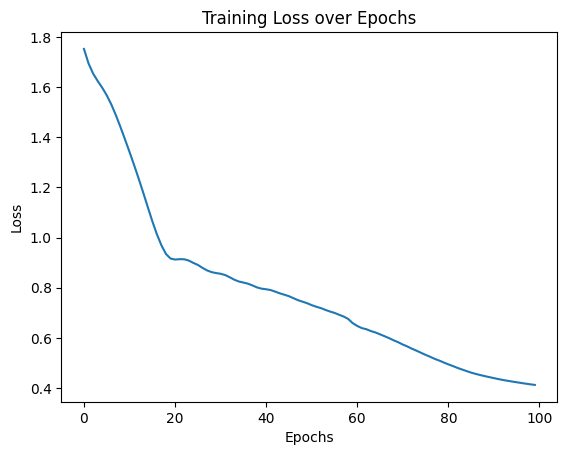

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import sys
import numpy as np

# Ensure project root is on sys.path (adjust if your notebook's cwd differs)
sys.path.append('../../')

# Import MLP and create model instance
from SRC.models.ann_model import MLP
import os
torch.manual_seed(42)
model = MLP()

%matplotlib inline

# 1. Load the processed data from csv files
x_data = pd.read_csv('../../data/X_processed.csv')
y_data = pd.read_csv('../../data/y_processed.csv')

# Drop rows with missing values in features or target
df = pd.concat([x_data, y_data], axis=1).dropna()

# 2. Convert to values (NumPy arrays) and make labels zero-based integers
x = df[x_data.columns].values
y = df[y_data.columns[0]].values.astype(int) - 1  # convert to 0..C-1

# Train/test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

print("Train/Test split successful!")
print(f"Training samples: {len(x_train)}, Testing samples: {len(x_test)}")

# convert x features to float tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

# convert y labels to long tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Set the criterion of model to measure the error,how far off the prediction are from the actual labels. 
# And set the optimizer to update the model's parameters based on the computed gradients during training.
criterion = torch.nn.CrossEntropyLoss()
#choose the Adam optimizer, which is an adaptive learning rate optimization algorithm that has been shown to work well in practice for training neural networks.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.parameters

#Train the model
#Epochs? (one run through all the training data)
epochs = 100
losses = []
for i in range(epochs): 
    # Forward pass: compute predicted y by passing x to the model.
    y_pred = model.forward(x_train) #Get predicted results

    # Compute and print loss.
    loss = criterion(y_pred, y_train)
    #keep track of losses for plotting later
    losses.append(loss.detach().numpy())
    
    #print every 10 epochs
    if i % 10 == 0:
        print(f'Epoch {i}: add loss: {loss.item()}')
    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('Epochs')    
plt.title('Training Loss over Epochs')

# Save the trained weights to a 'models' directory or project root
save_dir = '../../models'
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, 'ofsted_ann_model.pt'))
print("Trained model weights saved successfully!")
